# AAV5 real data — profile model

This notebook works with `aav9.csv`, a real NGS dataset from an AAV9 capsid
directed-evolution / viability experiment (not the simulated `Protocol` used
elsewhere in `Modelization_V1`). Each row is one observed 7-amino-acid variant
(the same `(num_amino_acids=20, num_positions=7)` convention as
`sequence_classesV1.Protocol`) with:


- `target` — the log enrichment of post-viability count over the input `plasmid` pool,
- `error` — an estimated uncertainty on `target` (bounded in `[0, 2]`; smaller
  for variants with more reads)

**Goal of this notebook (task 1):** build the **profile model** — the same
`F` object as `Protocol.F_viab`, a
`(num_amino_acids, num_positions)` matrix where `F[a, i]` says how good/bad
amino acid `a` is at position `i`. The logic being encoded is literally: *if
sequences with amino acid A at position 1 tend to have high (good) log
enrichment, position 1 / AA-A gets a positive profile weight* — and
symmetrically for every other (amino acid, position) pair.

### 0. Setup

In [47]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/", one level below
# analysisV1.py -- add the parent dir so the sibling import resolves (same
# convention as ProfileMLP_recovery_nnx.ipynb in this folder).
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (analysisV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_teacher_weights, plot_topk_recovery

# Only needed for section 8 (ProfileMLP), imported here so section 0 is the single setup point.
import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm
from sequence_classesV1 import ProtocolV2, initialize_random_weights

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 real-data profile model 1.1"


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### 1. Load the data

In [48]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")
df.head()


68,776 variants, columns: ['sequence', 'target', 'error']


,sequence,target,error
0,AAACMFE,-7.167889,0.1
1,AAAFQEE,0.815779,0.1
2,AAAGCEN,-5.382741,0.1
3,AAALKGI,0.441829,0.1
4,AAANGCQ,-4.548073,0.1


### 1b. Target distribution

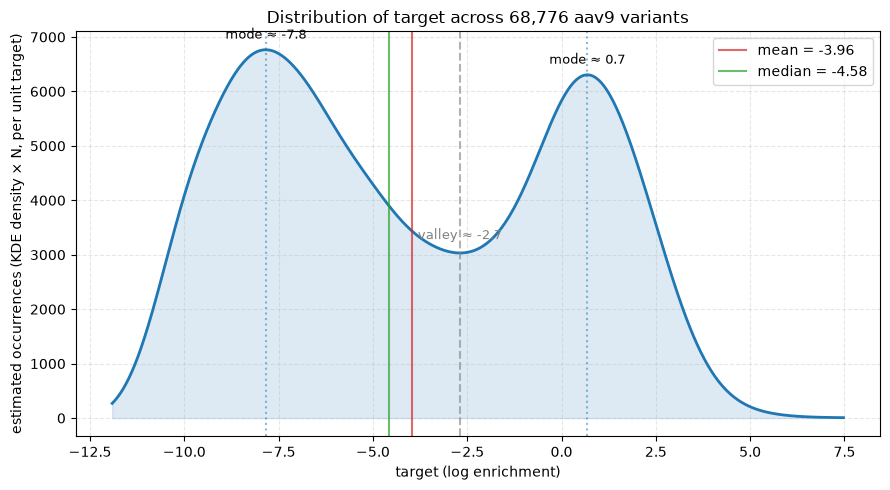

detected mode(s) at target ≈ [-7.84  0.68]


In [49]:
t = df["target"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t.min(), t.max(), 1000)
kde = gaussian_kde(t, bw_method=0.15)
occurrences = kde(grid) * len(t)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t.mean():.2f}")
ax.axvline(np.median(t), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t):,} aav9 variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


In [50]:
lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

print(f"num_positions={num_positions}  num_amino_acids={num_amino_acids}")

df[["target", "error"]].describe()


num_positions=7  num_amino_acids=20


,target,error
count,68776.000000,6.877600e+04
mean,-3.959911,1.000000e-01
std,4.209564,1.387789e-17
min,-11.911773,1.000000e-01
25%,-7.710318,1.000000e-01
50%,-4.583340,1.000000e-01
75%,0.087531,1.000000e-01
max,7.472986,1.000000e-01


In [51]:
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy()

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"seq_matrix[0] = {seq_matrix[0]}  ->  '{df['sequence'].iloc[0]}'")

seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
seq_matrix[0] = [ 0  0  0  1 10  4  3]  ->  'AAACMFE'


### 2. Building a supposed Ground Truth 

In [52]:
def F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions):
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    counts = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for aa in range(num_amino_acids):
            mask = seq_matrix[:, i] == aa
            counts[aa, i] = mask.sum()
            if mask.any():
                F[aa, i] = target[mask].mean() - baseline
    return F, counts

F_viab_GT, counts = F_groundtruth_viability(seq_matrix=seq_matrix, target=df['target'].to_numpy(), num_amino_acids=num_amino_acids, num_positions=num_positions)

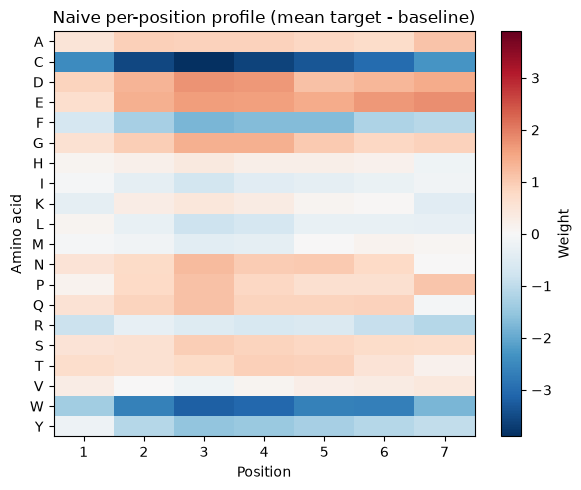

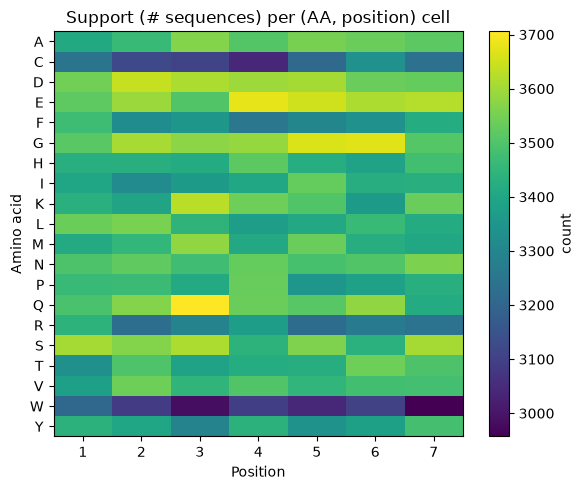

In [53]:
plot_teacher_weights(F_viab_GT, title="Naive per-position profile (mean target - baseline)")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(counts, aspect="auto", cmap="viridis")
ax.set_xlabel("Position")
ax.set_ylabel("Amino acid")
ax.set_xticks(range(num_positions))
ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
ax.set_yticks(range(num_amino_acids))
ax.set_yticklabels(AA_LABELS)
ax.set_title("Support (# sequences) per (AA, position) cell")
fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()


### 3. Learning the profile weights with an MLP

In [54]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [55]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [56]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [63]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)
y_train, y_test    = target[idx_train], target[idx_test]

### ------------ One Hot Encoding ------------ ###
# Raw per-position indices (0..19, AA_LABELS' alphabetical order) carry no numeric
# meaning -- amino acid 3 isn't "between" 2 and 4 in any biological sense -- so feeding
# them straight into nnx.Linear as floats forces the network to first rediscover the
# one-hot structure from scratch before it can learn anything else. One-hot expands
# each position into a length-20 indicator vector instead: (N, 7) -> (N, 7, 20) -> (N, 140).
seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]  # (N, L, A)
seq_oh = seq_oh.reshape(len(df), -1)                             # (N, L*A)

X_mlp_train_full = seq_oh[idx_train]
X_mlp_test        = seq_oh[idx_test]

print(f"X_mlp_train_full shape is {X_mlp_train_full.shape}")

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_mlp_train_full, y_train, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_mlp_test):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp, seed=0)


X_mlp_train_full shape is (34388, 140)
ProfileMLP -- train: 29,230  val: 5,158  test: 34,388


Training ProfileMLP:  20%|██        | 61/300 [00:03<00:15, 15.34it/s]

Early stopping at epoch 61 (best val MSE=3.0246)


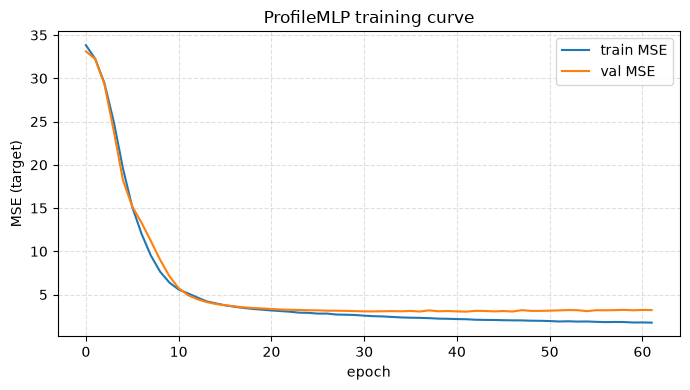

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


Pearson r (train): 0.9676
Pearson r (test):  0.9134

Held-out (test) top-k recovery:
  Top   1%   precision = 0.155   (random baseline = 0.010)
  Top   5%   precision = 0.419   (random baseline = 0.050)
  Top  10%   precision = 0.582   (random baseline = 0.100)
  Top  20%   precision = 0.740   (random baseline = 0.200)


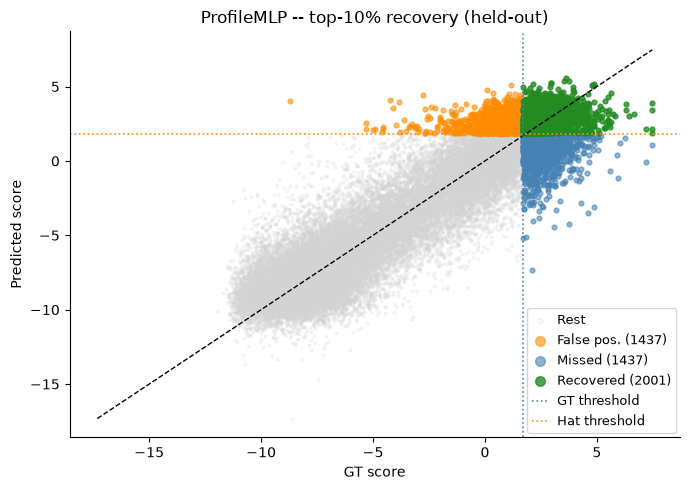

In [65]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_mlp = np.asarray(predict_scores(model_mlp, jnp.asarray(Xtr_mlp)))
pred_test_mlp  = np.asarray(predict_scores(model_mlp, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_mlp):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_mlp):.4f}")
print()
print("Held-out (test) top-k recovery:")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_mlp, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_mlp, k_frac=0.10, title="ProfileMLP -- top-10% recovery (held-out)")
plt.show()


In [66]:
def extract_effective_F(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Single-mutant scan against real background sequences: for a background s and mutation
    p->a, M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other
    positions. Averaged over many backgrounds, F is recovered up to a global additive
    constant.

    backgrounds : (M, L) real sequences as raw amino-acid indices, e.g. a random subsample
                  of seq_matrix. Mutants are built in raw-index space (simplest way to flip
                  a single position), then one-hot encoded right before scoring since model
                  now expects one-hot (N, L*A) input, matching training.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)      # (n, L) raw indices
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)  # (n, L*A) one-hot

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L)
    return F_hat


rng_bg      = np.random.default_rng(0)
M_backgrounds = 256
bg_idx      = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
backgrounds = seq_matrix[bg_idx]

F_mlp = extract_effective_F(model_mlp, backgrounds)


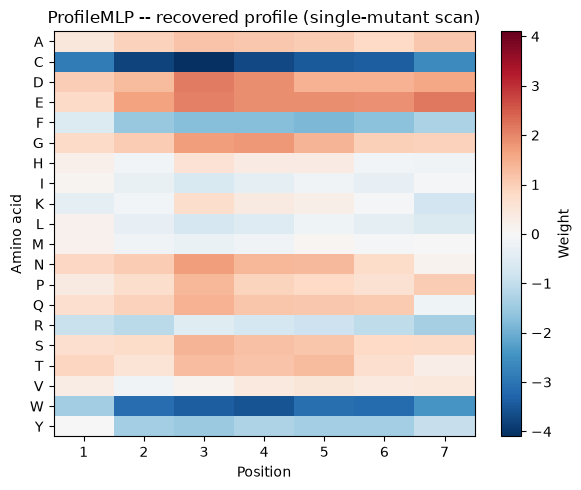

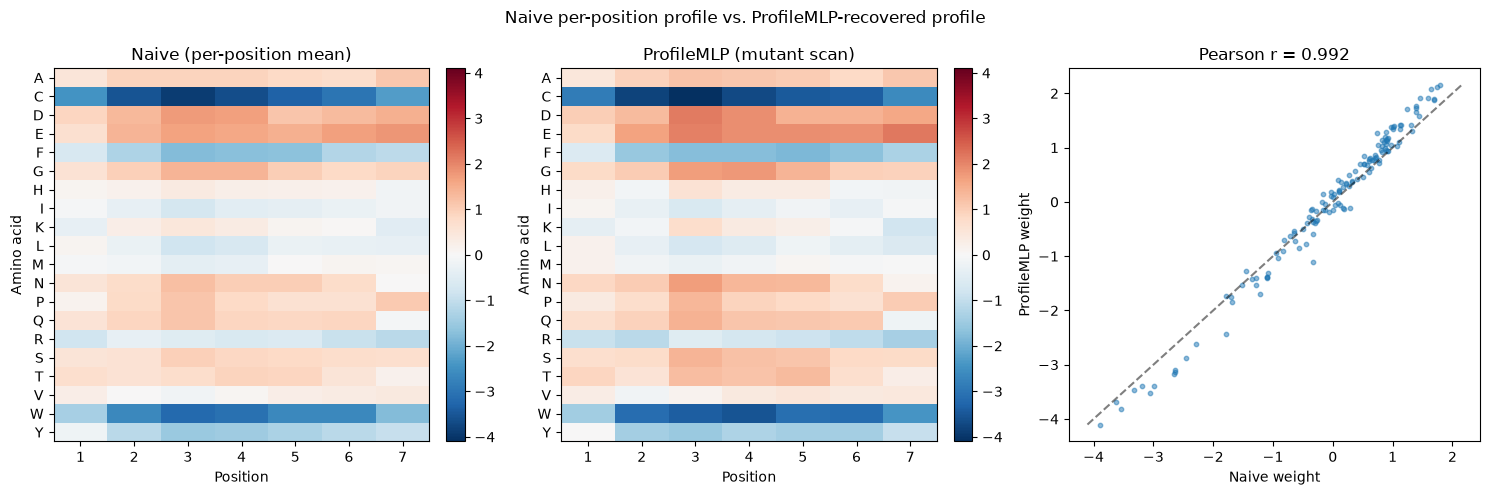

In [67]:
plot_teacher_weights(F_mlp, title="ProfileMLP -- recovered profile (single-mutant scan)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_mlp).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_mlp, "ProfileMLP (mutant scan)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_mlp.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_mlp.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_mlp.min()), max(F_viab_GT.max(), F_mlp.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("ProfileMLP weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. ProfileMLP-recovered profile")
fig.tight_layout()
plt.show()


### 3b. Pairwise (J) interactions: naive vs ProfileMLP

Section 2's naive profile only captures each position's own AVERAGE effect — it can't see
whether two positions interact (e.g. amino acid A being good at position 1 only when
position 4 has amino acid B). This extends the same two recipes already used for `F` to the
pairwise coupling `J`:

- **Naive J** — the same "group real sequences and average their target" logic as
  `F_groundtruth_viability`, extended to position PAIRS: for every (position i, position j,
  amino acid a, amino acid b), average the target of sequences that actually carry (a at i)
  AND (b at j), then subtract off the baseline and each position's own naive single-site
  effect (already known from `F_viab_GT`) — what's left over is the naive pairwise term.
- **ProfileMLP J** — `extract_effective_F`'s single-mutant scan extended to a DOUBLE-mutant
  scan against the already-trained `model_mlp` (same idea as `extract_effective_FJ` in
  `DEEPMLP_nnx_recovery.ipynb`, minus that notebook's `T` temperature scaling — real `target`
  isn't on that simulated scale).

The two are then compared directly: per-position-pair coupling-strength heatmaps side by
side, plus a raw-entry scatter restricted to cells where the naive estimate had enough real
sequences behind it to be trustworthy.

In [ ]:
def J_groundtruth_naive(seq_matrix, target, F, baseline, num_amino_acids, num_positions, min_support=5):
    """
    Naive per-pair pairwise-interaction estimate: for every position pair (i, j) and
    amino-acid pair (a, b), take the mean target of the real sequences that actually carry
    (a at i) AND (b at j), then subtract off what the baseline and each position's own
    single-site naive effect (F[a, i], F[b, j]) already explain -- what's left over is the
    naive estimate of positions i/j's PAIRWISE (epistatic) contribution, J[i, j, a, b].
    Mirrors J[j, i, b, a] = J[i, j, a, b], matching sequence_classesV1.build_J's convention.
    Cells with fewer than min_support supporting sequences are left as NaN (too few
    observations to trust the mean) -- same convention as F_groundtruth_viability's counts.

    Returns
    -------
    J, support : (L, L, A, A) naive interaction estimate (NaN on the diagonal i==j, and on
    any (i, j, a, b) with too little support) and the (L, L, A, A) raw supporting-sequence
    counts (useful to judge how much to trust a given cell).
    """
    L, A = num_positions, num_amino_acids
    J = np.full((L, L, A, A), np.nan)
    support = np.zeros((L, L, A, A), dtype=int)

    # Precompute each position's per-amino-acid boolean mask once, reused across every
    # partner position instead of recomputing "sequence has amino acid a at position i"
    # A*(L-1) times.
    position_masks = [[seq_matrix[:, i] == a for a in range(A)] for i in range(L)]

    for i in range(L):
        for j in range(i + 1, L):
            for a in range(A):
                mask_a = position_masks[i][a]
                if not mask_a.any():
                    continue
                for b in range(A):
                    mask = mask_a & position_masks[j][b]
                    n = int(mask.sum())
                    support[i, j, a, b] = support[j, i, b, a] = n
                    if n >= min_support:
                        val = target[mask].mean() - baseline - F[a, i] - F[b, j]
                        J[i, j, a, b] = J[j, i, b, a] = val
    return J, support


J_naive, support_naive = J_groundtruth_naive(
    seq_matrix, target, F_viab_GT, baseline=target.mean(),
    num_amino_acids=num_amino_acids, num_positions=num_positions, min_support=5,
)

off_diag = ~np.eye(num_positions, dtype=bool)
print(f"J_naive: {(~np.isnan(J_naive)).sum():,} / {J_naive.size:,} cells filled "
      f"({np.isnan(J_naive[off_diag]).mean() * 100:.1f}% of off-diagonal cells still NaN, "
      f"median support {np.median(support_naive[off_diag]):.0f} sequences/cell)")


In [ ]:
def extract_effective_FJ_mlp(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Double-mutant scan against the same `backgrounds` used by `extract_effective_F`'s
    single-mutant scan: for a background s and a JOINT mutation (p->a, q->b),
    M(s^{p->a,q->b}) - M(s) isolates f_p(a) + f_q(b) + j_pq(a,b), up to terms that depend on
    s's other positions. Averaged over backgrounds, subtracting the single-site effects
    (recomputed here from the SAME scan, so they're self-consistent with the pairwise term)
    leaves j_pq(a,b) -- the model's own effective pairwise coupling. Same "zero-sum-gauge"
    caveat as DEEPMLP_nnx_recovery.ipynb's extract_effective_FJ (each position's row/column
    mean is already subtracted out of J), but with no `T` scaling: this model was trained
    directly on the real (already-log-scale) target, unlike the simulated Protocol's
    T-normalized scores.

    Returns
    -------
    F_hat, J_hat : (A, L) single-site effects (same convention as extract_effective_F) and
    (L, L, A, A) pairwise couplings (NaN on the diagonal i==j, where "interaction" is
    undefined).
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)  # (n, L) raw indices

    # One-hot encoded and scored batch by batch -- x_all alone is ~2.2M rows here (256
    # backgrounds x (1 + L*A + n_pairs*A*A) mutants each), encoding it to one-hot all at once
    # would briefly need >1GB; chunking keeps peak memory small.
    scores_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk_oh = np.eye(A, dtype=np.float32)[x_all[start : start + batch_size]].reshape(-1, L * A)
        scores_chunks.append(np.asarray(predict_scores(model, jnp.asarray(chunk_oh))))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M : M + n_single].reshape(M, L, A)
    double_scores = scores[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L), matches extract_effective_F

    double_avg = double_scores.mean(axis=0)  # (n_pairs, A, A)
    J_hat = np.full((L, L, A, A), np.nan, dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij    = double_avg[k] - mean_score - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij
        J_hat[j, i] = delta_ij.T
    return F_hat, J_hat


F_mlp_fj, J_mlp = extract_effective_FJ_mlp(model_mlp, backgrounds)
print(f"Pearson r (F_mlp_fj vs F_mlp, sanity check -- same scan run twice): "
      f"{pearson(F_mlp.ravel(), F_mlp_fj.ravel()):.4f}")


In [ ]:
def coupling_strength(J):
    """(L, L, A, A) -> (L, L) mean |J_ij(a, b)| per position pair; NaN cells (no/too little
    support) are skipped rather than propagated, so one sparse cell doesn't NaN out its
    whole (i, j) pair. The diagonal (i == j, "interaction with itself") is left NaN directly,
    without ever calling nanmean on an all-NaN slice (which numpy would warn about)."""
    L = J.shape[0]
    off_diag = ~np.eye(L, dtype=bool)
    strength = np.full((L, L), np.nan)
    strength[off_diag] = np.nanmean(np.abs(J[off_diag]), axis=(1, 2))
    return strength

strength_naive = coupling_strength(J_naive)
strength_mlp   = coupling_strength(J_mlp)
vmax_strength  = np.nanmax([strength_naive, strength_mlp])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, S, title in [(axes[0], strength_naive, "Naive J (real-data means, minus marginals)"),
                      (axes[1], strength_mlp,   "ProfileMLP J (double-mutant scan)")]:
    im = ax.imshow(S, cmap="viridis", vmin=0, vmax=vmax_strength)
    ax.set_xlabel("Position j")
    ax.set_ylabel("Position i")
    ax.set_xticks(range(num_positions)); ax.set_xticklabels(range(1, num_positions + 1))
    ax.set_yticks(range(num_positions)); ax.set_yticklabels(range(1, num_positions + 1))
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="mean |J|", fraction=0.046, pad=0.04)

# Raw-entry scatter, restricted to cells where the naive estimate actually had enough
# supporting sequences (min_support) to be trustworthy -- ProfileMLP's J is defined
# everywhere off-diagonal, but only compared where there's a real naive value to check it
# against.
mask_support = ~np.isnan(J_naive)
j_naive_flat = J_naive[mask_support]
j_mlp_flat   = J_mlp[mask_support]
r_J = pearson(j_naive_flat, j_mlp_flat)

axes[2].scatter(j_naive_flat, j_mlp_flat, s=6, alpha=0.25)
lims = [min(j_naive_flat.min(), j_mlp_flat.min()), max(j_naive_flat.max(), j_mlp_flat.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive J")
axes[2].set_ylabel("ProfileMLP J")
axes[2].set_title(f"Pearson r = {r_J:.3f}  (n={mask_support.sum():,} cells)")

fig.suptitle("Naive vs ProfileMLP pairwise (J) interactions")
fig.tight_layout()
plt.show()


### 4. Direct profile model — construct the 140 weights directly

`ProfileMLP` above only reveals an effective `F` indirectly: it predicts a
scalar score through a black-box network, then `F` has to be pulled out
afterward with an expensive single-mutant scan. Here the model *is* the
`(num_amino_acids, num_positions)` profile matrix — no hidden layers, no
per-sequence nonlinearity: `score(seq) = bias + sum_i F[seq_i, i]`, the
exact functional form the naive profile already uses. It's trained with the
same nnx machinery as section 3 (`train_profile_mlp`, reused via its
`model=` warm-start argument), but the regression target for each sequence
is the score the **naive** profile (`F_viab_GT`) would predict for it — not
the noisy real `target` — so this checks whether gradient descent, using
this project's own training loop, converges to the same answer as the
closed-form per-position averaging.

# This does not work, we just find the noisy distribution, our goal is to predict the log enrichment of a variants base of his sequence, this deterministic model is easy to find by grandient descent but it is the noisy distribution, we don't want to recover this exact distribution.

In [68]:
raise SystemExit("checkpoint — stop ici")

SystemExit: checkpoint — stop ici

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
class DirectProfileModel(nnx.Module):
    """
    The model *is* the profile matrix: F (num_amino_acids, num_positions) and a scalar bias
    are the only trainable parameters, used exactly like Protocol.compute_score's profile
    term -- score(seq) = bias + sum_i F[seq_i, i]. `train`/`rngs` are accepted (unused) only
    so this matches ProfileMLP's call signature and can be dropped straight into train_step/
    eval_step/train_profile_mlp without changing any of that code.
    """

    def __init__(self, num_amino_acids: int, num_positions: int, *, rngs: nnx.Rngs):
        self.F    = nnx.Param(jax.random.normal(rngs.params(), (num_amino_acids, num_positions)) * 0.01)
        self.bias = nnx.Param(jnp.zeros(()))

    def __call__(self, x: jax.Array, *, train: bool = False, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        idx = x.astype(jnp.int32)
        return self.F[idx, jnp.arange(idx.shape[1])].sum(axis=1) + self.bias[...]


In [ ]:
baseline   = target.mean()
naive_pred = baseline + F_viab_GT[seq_matrix, np.arange(num_positions)].sum(axis=1)
print(f"Pearson r (naive_pred vs real target): {pearson(target, naive_pred):.4f}")

# Same idx_train/idx_test/seq_matrix split as section 3's ProfileMLP -- only the regression
# target changes (naive_pred instead of the real target).
y_naive_train = naive_pred[idx_train]
y_naive_test  = naive_pred[idx_test]

Xtr_direct, ytr_direct, Xva_direct, yva_direct = split_train_val(X_mlp_train_full, y_naive_train, val_frac=0.15, seed=0)
print(f"DirectProfileModel -- train: {len(Xtr_direct):,}  val: {len(Xva_direct):,}  test: {len(X_mlp_test):,}")

model_direct_init = DirectProfileModel(num_amino_acids=num_amino_acids, num_positions=num_positions, rngs=nnx.Rngs(0))
model_direct, hist_direct = train_profile_mlp(
    Xtr_direct, ytr_direct, Xva_direct, yva_direct, model=model_direct_init, seed=0
)


Pearson r (naive_pred vs real target): 0.7788
DirectProfileModel -- train: 52,614  val: 9,284  test: 6,878


Training ProfileMLP: 100%|██████████| 30/30 [00:00<00:00, 48.19it/s]


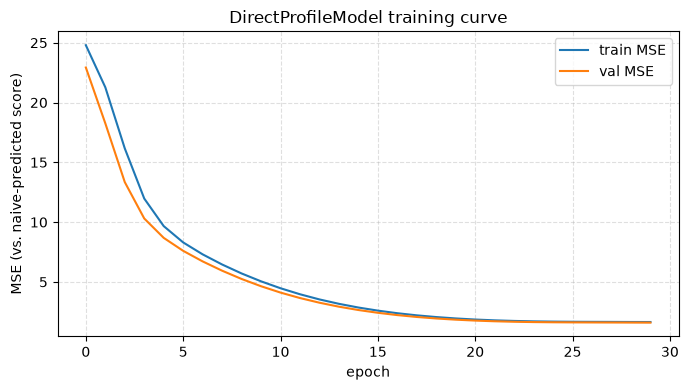

Pearson r (predictions vs. naive-predicted scores, held-out test): 0.9703
Pearson r (F_direct vs F_viab_GT, raw 140 weights): 0.9630


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_direct["train_loss"], label="train MSE")
ax.plot(hist_direct["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (vs. naive-predicted score)")
ax.set_title("DirectProfileModel training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_test_direct = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))
print(f"Pearson r (predictions vs. naive-predicted scores, held-out test): {pearson(y_naive_test, pred_test_direct):.4f}")

F_direct = np.array(model_direct.F[...])
print(f"Pearson r (F_direct vs F_viab_GT, raw 140 weights): {pearson(F_viab_GT.ravel(), F_direct.ravel()):.4f}")


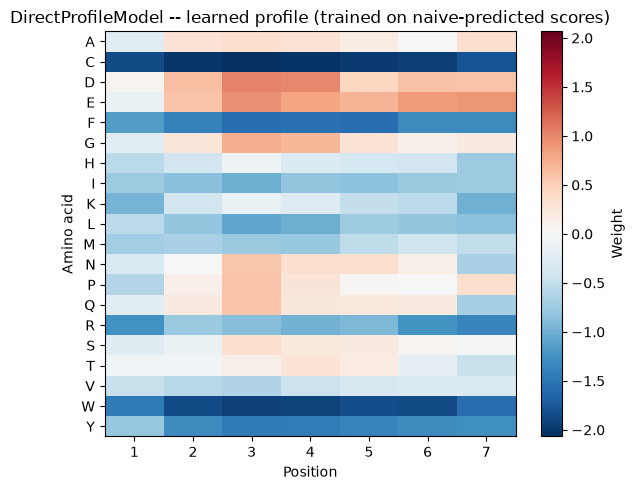

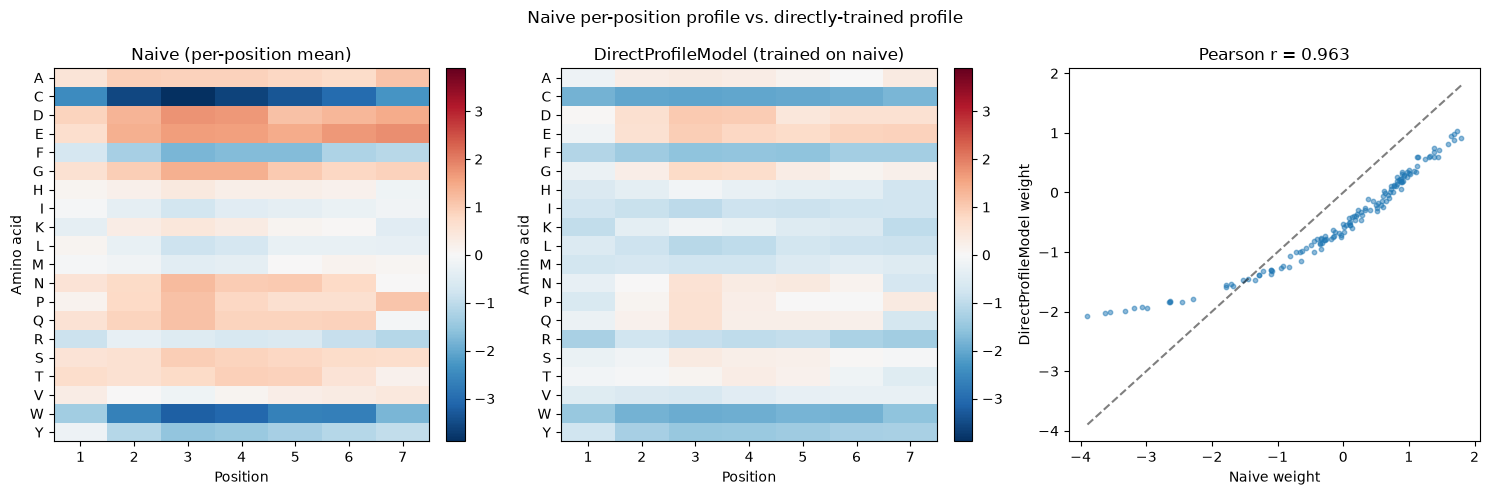

In [ ]:
plot_teacher_weights(F_direct, title="DirectProfileModel -- learned profile (trained on naive-predicted scores)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_direct).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_direct, "DirectProfileModel (trained on naive)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_direct.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_direct.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_direct.min()), max(F_viab_GT.max(), F_direct.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("DirectProfileModel weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. directly-trained profile")
fig.tight_layout()
plt.show()


Pearson r (train): 0.7548
Pearson r (test):  0.7544

Held-out (test) top-k recovery vs the REAL target (not naive_pred):
  Top   1%   precision = 0.000   (random baseline = 0.010)
  Top   5%   precision = 0.108   (random baseline = 0.050)
  Top  10%   precision = 0.291   (random baseline = 0.100)
  Top  20%   precision = 0.572   (random baseline = 0.200)


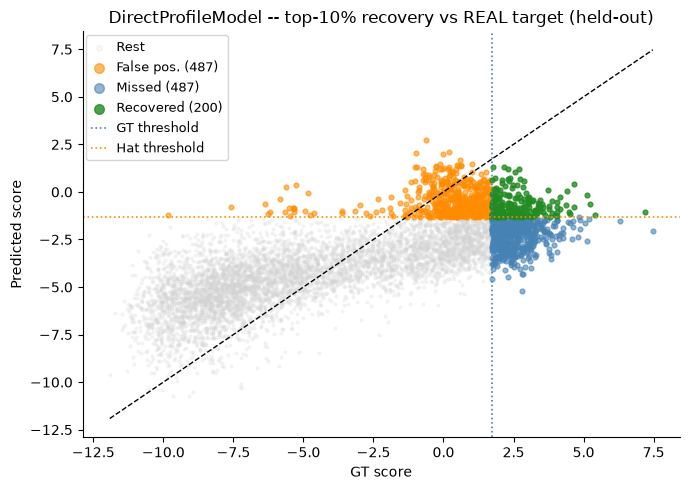

In [ ]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_direct = np.asarray(predict_scores(model_direct, jnp.asarray(Xtr_mlp)))
pred_test_direct  = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_direct):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_direct):.4f}")
print()
print("Held-out (test) top-k recovery vs the REAL target (not naive_pred):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_direct, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_direct, k_frac=0.10, title="DirectProfileModel -- top-10% recovery vs REAL target (held-out)")
plt.show()


**Why MSE → 0 during training:** `naive_pred` is, by construction, exactly
`bias + sum_i F[seq_i, i]` — the same functional form `DirectProfileModel`
uses. There's no noise in that target: it's a deterministic linear function
of the 140+1 unknowns, and `DirectProfileModel` has exactly those 140+1
unknowns as its only parameters. MSE is a convex (quadratic) function of a
linear model's own parameters, and a zero-residual solution provably exists
(`F = F_viab_GT`, `bias = baseline`) — so Adam just has to find that global
minimum, which it does (train *and* val loss hit ~0, since neither split
has any label noise to leave a residual). This is not overfitting: it's
gradient descent rediscovering the exact linear system that generated the
label in the first place.

**Why recovering ≈ the same `F` doesn't mean recovering the best real
variants:** matching `F_viab_GT` only proves the training pipeline
converges correctly — it says nothing about whether the *naive* profile
itself is good at ranking real variants, and `DirectProfileModel` was
deliberately trained to reproduce naive, not the real `target`, so its
ceiling is capped at naive's own accuracy (r ≈ 0.78 either way). At r²≈0.61
that ceiling sounds decent — but precision@k above shows it collapses at
the extreme top (**top-1% precision = 0.000**), while `ProfileMLP` two
sections up — *lower* overall r (0.36) — gets **7.4× the random baseline**
at that same top-1% (0.074 vs. 0.010). An additive, single-site model's own
best-ranked sequences necessarily cluster around "the single best amino
acid at every position" — it structurally cannot represent any real
variant whose extreme enrichment comes from a *specific combination* of
positions (epistasis). It gets the coarse split right (this project's own
bimodal target from section 1b: "probably dead" vs. "probably viable" —
that's most of where the top-10/20% numbers come from) but is blind to
whatever finer, non-additive effect separates the literal best variants
from the merely-good ones — and `ProfileMLP`, despite a noisier overall
fit, can at least partially see that.